In [145]:
import pandas as pd

In [146]:
df = pd.read_csv("data.csv")

# nettoyage minimum
df["WELL"] = df["WELL"].astype(str).str.strip().str.upper()
df["DATE"] = pd.to_datetime(df["DATE"])

In [147]:
list(df.columns)

['WELL',
 'DATE',
 'HOURS',
 'WHP',
 'WHT',
 'C2M',
 'C3',
 'C4',
 'C5P',
 'H2O',
 'W_GAS',
 'S_GAS',
 'LPG_VOL',
 'LPG_MASS',
 'COND_VOL',
 'COND_MASS',
 'WATER',
 'prodindex',
 'WLP']

In [148]:
def find_never_active_wells(df):
    # somme des heures par puits
    activity = df.groupby("WELL")["HOURS"].sum()

    # puits jamais actifs
    never_active = activity[activity == 0]

    print("===== PUITS JAMAIS ACTIFS =====")
    print(f"Nombre: {len(never_active)}")

    if len(never_active) > 0:
        print(never_active.index.tolist())

    return never_active.index.tolist()

In [149]:
never_active_wells = find_never_active_wells(df)

===== PUITS JAMAIS ACTIFS =====
Nombre: 10
['TFT-112', 'TFT-301', 'TFT-312', 'TFT-321', 'TFT-322', 'TFT-323', 'TFW-1', 'TFY-18', 'TFY-29', 'TML-1']


In [150]:
df["ACTIVE"] = (df["HOURS"] > 0).astype(int)

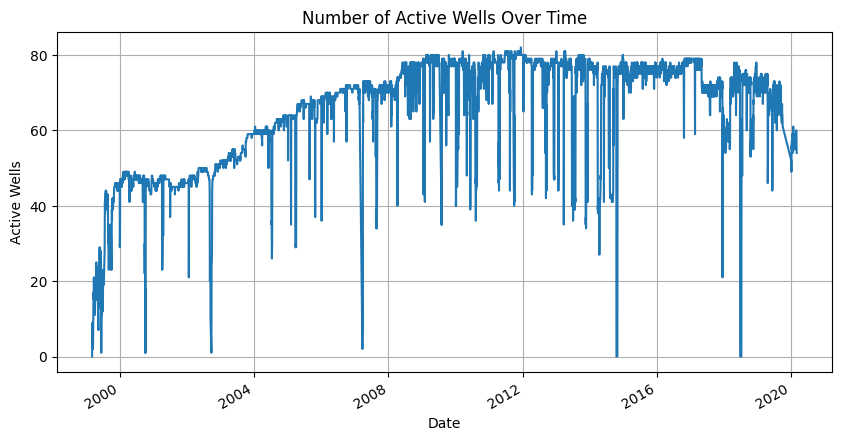

In [151]:
import matplotlib.pyplot as plt

activity_per_day = df.groupby('DATE')['ACTIVE'].sum()

plt.figure(figsize=(10,5))
activity_per_day.plot()

plt.title("Number of Active Wells Over Time")
plt.xlabel("Date")
plt.ylabel("Active Wells")

plt.grid()
plt.show()

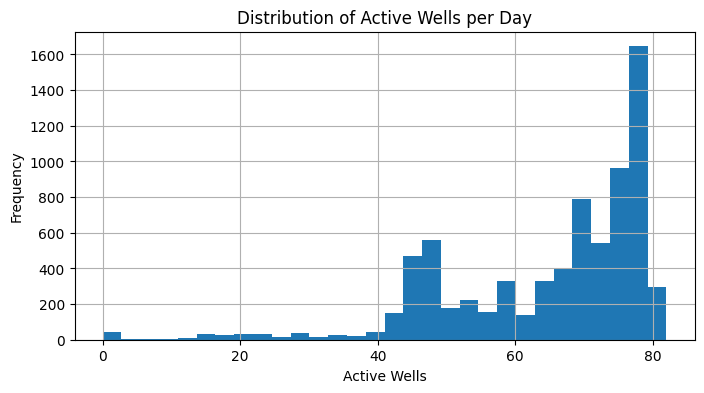

In [152]:
plt.figure(figsize=(8,4))

activity_per_day.hist(bins=30)

plt.title("Distribution of Active Wells per Day")
plt.xlabel("Active Wells")
plt.ylabel("Frequency")

plt.show()

In [153]:
activity = (
    df.groupby("WELL")["ACTIVE"]
    .sum()
    .reset_index()
    .rename(columns={"ACTIVE": "JOURS_ACTIFS"})
)

In [154]:
activity = activity.sort_values(
    "JOURS_ACTIFS",
    ascending=False
)

print(activity.head(20))

        WELL  JOURS_ACTIFS
31  TFT-335Z          7282
51   TFT-355          7242
2    TFT-302          7232
14   TFT-317          7225
48   TFT-352          7223
42  TFT-346Z          7218
22   TFT-325          7216
54   TFT-358          7212
21   TFT-324          7198
43   TFT-347          7198
49   TFT-353          7193
40   TFT-344          7188
29  TFT-333Z          7186
33   TFT-337          7178
27   TFT-331          7172
15   TFT-318          7168
10   TFT-313          7159
45   TFT-349          7143
34   TFT-338          7139
32   TFT-336          7137


In [155]:
print(activity)

        WELL  JOURS_ACTIFS
31  TFT-335Z          7282
51   TFT-355          7242
2    TFT-302          7232
14   TFT-317          7225
48   TFT-352          7223
..       ...           ...
18   TFT-321             0
94     TFW-1             0
95    TFY-18             0
96    TFY-29             0
98     TML-1             0

[99 rows x 2 columns]


In [156]:
total_days = df["DATE"].nunique()

activity["TAUX_ACTIVITE_%"] = (
    activity["JOURS_ACTIFS"] / total_days * 100
)

activity = activity.sort_values(
    "TAUX_ACTIVITE_%",
    ascending=False
)
print(total_days)
print(activity.head(20))


7494
        WELL  JOURS_ACTIFS  TAUX_ACTIVITE_%
31  TFT-335Z          7282        97.171070
51   TFT-355          7242        96.637310
2    TFT-302          7232        96.503870
14   TFT-317          7225        96.410462
48   TFT-352          7223        96.383774
42  TFT-346Z          7218        96.317054
22   TFT-325          7216        96.290366
54   TFT-358          7212        96.236990
21   TFT-324          7198        96.050173
43   TFT-347          7198        96.050173
49   TFT-353          7193        95.983453
40   TFT-344          7188        95.916733
29  TFT-333Z          7186        95.890045
33   TFT-337          7178        95.783293
27   TFT-331          7172        95.703229
15   TFT-318          7168        95.649853
10   TFT-313          7159        95.529757
45   TFT-349          7143        95.316253
34   TFT-338          7139        95.262877
32   TFT-336          7137        95.236189


In [157]:
champion_wells_list = df["WELL"].unique().tolist()
print(" WELLS:")
print(champion_wells_list)

 WELLS:
['TFT-112', 'TFT-301', 'TFT-302', 'TFT-303', 'TFT-304', 'TFT-305', 'TFT-306', 'TFT-308', 'TFT-310', 'TFT-312', 'TFT-313', 'TFT-314', 'TFT-315', 'TFT-316', 'TFT-317', 'TFT-318', 'TFT-319', 'TFT-320', 'TFT-321', 'TFT-322', 'TFT-323', 'TFT-324', 'TFT-325', 'TFT-326', 'TFT-327', 'TFT-329Z', 'TFT-330', 'TFT-331', 'TFT-332', 'TFT-333Z', 'TFT-334Z', 'TFT-335Z', 'TFT-336', 'TFT-337', 'TFT-338', 'TFT-339', 'TFT-340', 'TFT-341Z', 'TFT-342', 'TFT-343', 'TFT-344', 'TFT-345', 'TFT-346Z', 'TFT-347', 'TFT-348', 'TFT-349', 'TFT-350', 'TFT-351', 'TFT-352', 'TFT-353', 'TFT-354', 'TFT-355', 'TFT-356', 'TFT-357', 'TFT-358', 'TFT-359', 'TFT-360', 'TFT-361', 'TFT-362', 'TFT-363', 'TFT-364', 'TFT-365', 'TFT-366', 'TFT-367', 'TFT-368', 'TFT-369', 'TFT-370', 'TFT-373', 'TFT-374', 'TFT-375', 'TFT-376', 'TFT-378', 'TFT-379', 'TFT-380', 'TFT-383', 'TFT-384', 'TFT-385', 'TFT-386', 'TFT-387', 'TFT-388', 'TFT-391', 'TFT-704', 'TFTW-371', 'TFTW-377Z', 'TFTW-389', 'TFTW-390Z', 'TFTW-394Z', 'TFTW-395Z', 'TFTW-3

In [158]:
# ==============================
# LISTE DATA FINALE
# ==============================
all_wells = []

# ==============================
# LOOP SUR LES 20 PUITS
# ==============================
for well_name in champion_wells_list:

    

    df_well = df[df["WELL"] == well_name].copy()

    if df_well.empty:
        continue

    # ===== PREPARER DATE =====
    df_well = df_well.sort_values("DATE")

    # ===== GRID COMPLETE =====
    full_dates = pd.date_range(
        df["DATE"].min(),
        df["DATE"].max()
    )

    df_well = df_well.set_index("DATE").reindex(full_dates)
    df_well.index.name = "DATE"
    df_well.reset_index(inplace=True)

    df_well["WELL"] = well_name

    # ===== GESTION TROUS =====
    df_well["HOURS"] = df_well["HOURS"].fillna(0)
    df_well["W_GAS"] = df_well["W_GAS"].fillna(0)
    df_well["WATER"] = df_well["WATER"].fillna(0)
    df_well["COND_VOL"] = df_well["COND_VOL"].fillna(0)
    
    df_well["WHP"] = df_well["WHP"].interpolate()
    df_well["WHT"] = df_well["WHT"].interpolate()

    df_well.loc[df_well["HOURS"] == 0, ["WHP","WHT"]] = 0

    # ===== COLONNES =====
    df_well = df_well[
        ["DATE","WELL","HOURS","WHP","WHT","W_GAS","WATER","COND_VOL"]
    ]

    df_well = df_well.sort_values("DATE").reset_index(drop=True)

    # ===== ADD LIST =====
    all_wells.append(df_well)

# ==============================
# CONCAT FINAL
# ==============================
df_final = pd.concat(all_wells, ignore_index=True)

df_final = df_final.sort_values(["WELL","DATE"])

df_final.to_csv("20_PUITS_CHAMPIONS_GRID.csv", index=False)

print("\n===== DATASET FINAL =====")
print("Nombre de puits:", df_final["WELL"].nunique())
print("Nombre lignes:", len(df_final))
print(df_final.head())


===== DATASET FINAL =====
Nombre de puits: 99
Nombre lignes: 759033
        DATE     WELL  HOURS  WHP  WHT  W_GAS  WATER  COND_VOL
0 1999-03-05  TFT-112    0.0  0.0  0.0    0.0    0.0       0.0
1 1999-03-06  TFT-112    0.0  0.0  0.0    0.0    0.0       0.0
2 1999-03-07  TFT-112    0.0  0.0  0.0    0.0    0.0       0.0
3 1999-03-08  TFT-112    0.0  0.0  0.0    0.0    0.0       0.0
4 1999-03-09  TFT-112    0.0  0.0  0.0    0.0    0.0       0.0


In [159]:
df_full = df_final.copy()

df_full["IS_STOPPED"] = (df_full["HOURS"] == 0).astype(int)


print("\n===== STEP 5 DONE =====")
print(df_full["IS_STOPPED"].value_counts())


===== STEP 5 DONE =====
IS_STOPPED
0    485774
1    273259
Name: count, dtype: int64


In [160]:
# STEP 6: SUPPRIMER jours arrêt
# ==============================

df_clean = df_full[df_full["IS_STOPPED"] == 0].copy()


print("\n===== STEP 6 DONE =====")


===== STEP 6 DONE =====


In [161]:
# sécurité HOURS
df_clean["HOURS"] = df_clean["HOURS"].fillna(0)

# interpolation PAR PUITS
df_clean["WHP"] = (
    df_clean.groupby("WELL")["WHP"]
    .transform(lambda x: x.interpolate())
)

df_clean["WHT"] = (
    df_clean.groupby("WELL")["WHT"]
    .transform(lambda x: x.interpolate())
)

# correction physique
df_clean.loc[df_clean["HOURS"] == 0, ["WHP","WHT","W_GAS","WATER","COND_VOL"]] = 0


print("\n===== STEP 7 DONE =====")


===== STEP 7 DONE =====


In [162]:
def cap_outliers(df, col, lower_q=0.001, upper_q=0.999):

    lower = df[col].quantile(lower_q)
    upper = df[col].quantile(upper_q)

    # 🔥 IMPORTANT FIX
    if col in ["WHP", "WHT"]:
        lower = 0  # never cap physically valid low pressure

    if col in ["W_GAS", "WATER", "COND_VOL"]:
        lower = 0  # production can't be negative

    df[col] = df[col].clip(lower, upper)

    return df

In [163]:
cols_to_clean = ["WHP", "WHT", "W_GAS", "WATER", "COND_VOL"]

for col in cols_to_clean:
    df_clean = cap_outliers(df_clean, col)

In [164]:
print("\n===== FINAL VERIFICATION =====")

for col in cols_to_clean:
    print(f"\n{col}")
    print("Min:", df_clean[col].min())
    print("Max:", df_clean[col].max())
    print("99.9%:", df_clean[col].quantile(0.999))


===== FINAL VERIFICATION =====

WHP
Min: 0.0
Max: 140.0
99.9%: 140.0

WHT
Min: 0.0
Max: 71.0
99.9%: 71.0

W_GAS
Min: 0.0
Max: 1.03408956
99.9%: 1.03408956

WATER
Min: 0.0
Max: 70.89387512207031
99.9%: 70.89387512207031

COND_VOL
Min: 0.0
Max: 242.224365234375
99.9%: 242.224365234375


In [165]:
# ==============================
# STEP 8: Ajouter DELTA_DAYS
# ==============================

df_clean = df_clean.sort_values(["WELL","DATE"])

df_clean["DELTA_DAYS"] = (
    df_clean.groupby("WELL")["DATE"]
    .diff()
    .dt.days
)

df_clean["DELTA_DAYS"] = df_clean["DELTA_DAYS"].fillna(1)


print("\n===== STEP 8 DONE =====")


===== STEP 8 DONE =====


In [166]:
# STEP 9: Dataset final
# ==============================

df_final_model = df_clean[
    ["DATE","WELL","HOURS","WHP","WHT","W_GAS","WATER","COND_VOL","DELTA_DAYS"]
]

df_final_model = df_final_model.sort_values(
    ["WELL","DATE"]
).reset_index(drop=True)

df_final_model.to_csv("step9_final_dataset.csv", index=False)

print("\n===== FINAL DATASET =====")
print(df_final_model.head())

print("\nNaN CHECK:")
print(df_final_model.isna().sum())


===== FINAL DATASET =====
        DATE     WELL  HOURS    WHP   WHT     W_GAS     WATER   COND_VOL  \
0 1999-03-29  TFT-302    3.5  100.0  47.0  0.056289  0.085220  11.448846   
1 1999-04-01  TFT-302    8.3  100.0  53.0  0.127752  0.229435  24.612087   
2 1999-04-04  TFT-302   15.8  100.0  52.0  0.243890  0.438012  46.986710   
3 1999-04-05  TFT-302   24.0   99.0  54.0  0.371549  0.662891  71.110085   
4 1999-04-06  TFT-302   24.0  100.0  55.0  0.371642  0.667447  71.598801   

   DELTA_DAYS  
0         1.0  
1         3.0  
2         3.0  
3         1.0  
4         1.0  

NaN CHECK:
DATE          0
WELL          0
HOURS         0
WHP           0
WHT           0
W_GAS         0
WATER         0
COND_VOL      0
DELTA_DAYS    0
dtype: int64


In [167]:
wellnames = df_final_model["WELL"].unique()
wellnames

<ArrowStringArray>
[  'TFT-302',   'TFT-303',   'TFT-304',   'TFT-305',   'TFT-306',   'TFT-308',
   'TFT-310',   'TFT-313',   'TFT-314',   'TFT-315',   'TFT-316',   'TFT-317',
   'TFT-318',   'TFT-319',   'TFT-320',   'TFT-324',   'TFT-325',   'TFT-326',
   'TFT-327',  'TFT-329Z',   'TFT-330',   'TFT-331',   'TFT-332',  'TFT-333Z',
  'TFT-334Z',  'TFT-335Z',   'TFT-336',   'TFT-337',   'TFT-338',   'TFT-339',
   'TFT-340',  'TFT-341Z',   'TFT-342',   'TFT-343',   'TFT-344',   'TFT-345',
  'TFT-346Z',   'TFT-347',   'TFT-348',   'TFT-349',   'TFT-350',   'TFT-351',
   'TFT-352',   'TFT-353',   'TFT-354',   'TFT-355',   'TFT-356',   'TFT-357',
   'TFT-358',   'TFT-359',   'TFT-360',   'TFT-361',   'TFT-362',   'TFT-363',
   'TFT-364',   'TFT-365',   'TFT-366',   'TFT-367',   'TFT-368',   'TFT-369',
   'TFT-370',   'TFT-373',   'TFT-374',   'TFT-375',   'TFT-376',   'TFT-378',
   'TFT-379',   'TFT-380',   'TFT-383',   'TFT-384',   'TFT-385',   'TFT-386',
   'TFT-387',   'TFT-388',   'TFT

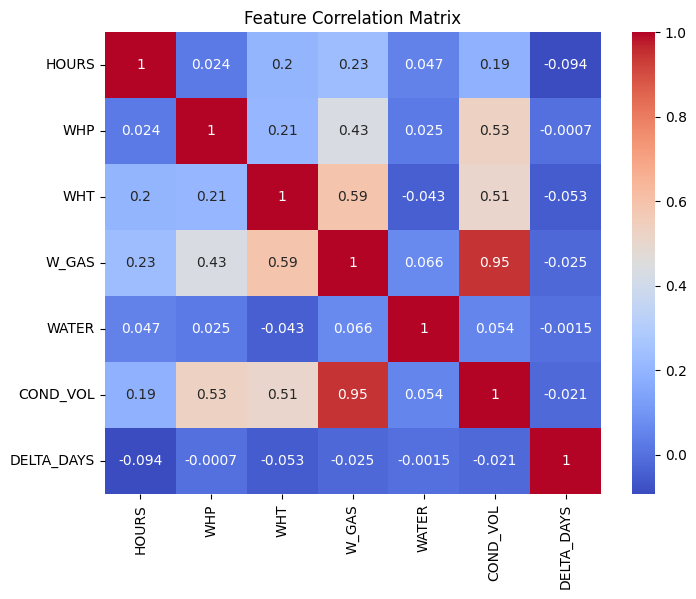

In [168]:
import seaborn as sns

plt.figure(figsize=(8,6))

corr = df_final_model.drop(columns=["DATE","WELL"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

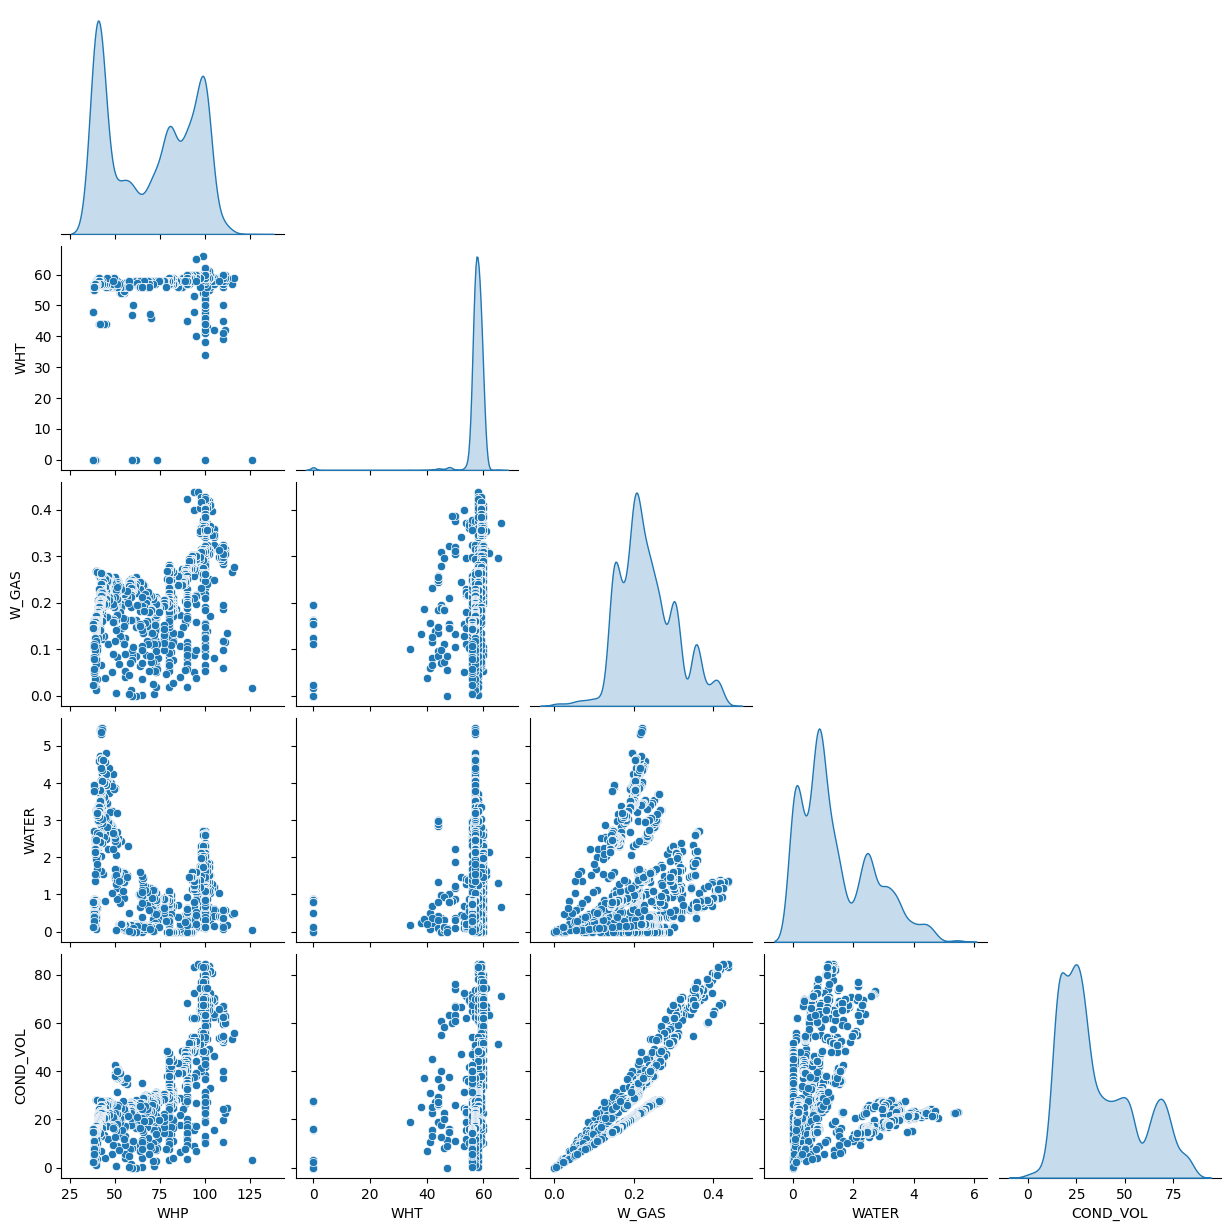

In [169]:
features = ["WHP","WHT","W_GAS","WATER","COND_VOL"]

well_df = df_final_model[
    df_final_model['WELL'] == wellnames[0]
][features]

sns.pairplot(well_df.dropna(), corner=True, diag_kind='kde')

plt.show()

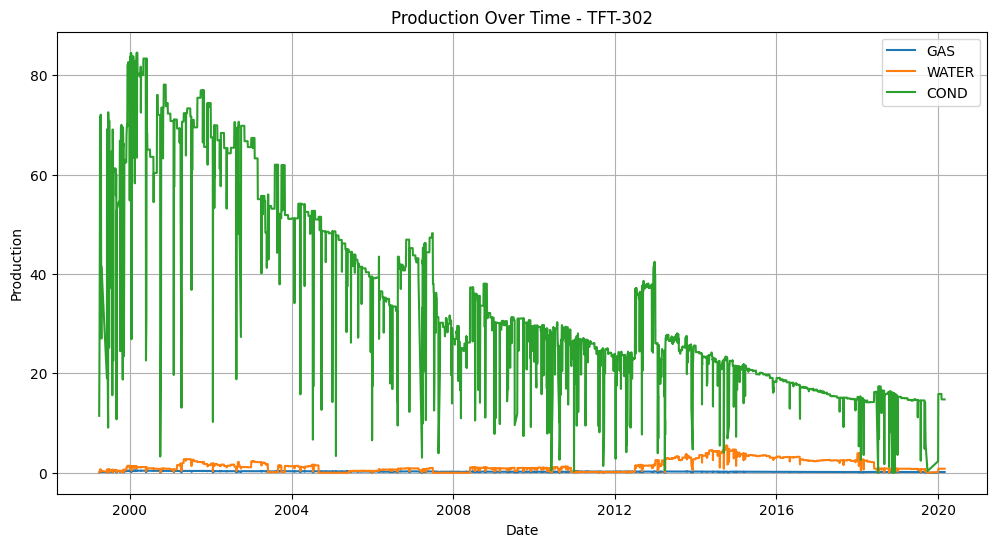

In [170]:
well = wellnames[0]

well_df = df_final_model[df_final_model["WELL"] == well]

plt.figure(figsize=(12,6))

plt.plot(well_df["DATE"], well_df["W_GAS"], label="GAS")
plt.plot(well_df["DATE"], well_df["WATER"], label="WATER")
plt.plot(well_df["DATE"], well_df["COND_VOL"], label="COND")

plt.legend()
plt.title(f"Production Over Time - {well}")

plt.xlabel("Date")
plt.ylabel("Production")

plt.grid()
plt.show()

In [171]:
from ipywidgets import interact
wellnames = df_final_model["WELL"].unique().tolist()
wellnames_5 = wellnames[:5]
@interact(well=wellnames_5)
def boxdistplot(well):
    
    # Filter well
    df_temp = df_final_model[df_final_model['WELL'] == well].copy()
    
    # Drop non-numeric columns
    df_temp = df_temp.drop(['DATE', 'WELL'], axis=1)
    
    # Handle missing values (important)
    df_temp = df_temp.dropna()
    
    # Create subplots
    f, axes = plt.subplots(len(df_temp.columns), 2, figsize=(14, 4 * len(df_temp.columns)))
    
    # Loop over features
    for i, col in enumerate(df_temp.columns):
        
        # Distribution
        sns.histplot(df_temp[col], kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f"{col} - Distribution")
        
        # Boxplot
        sns.boxplot(x=df_temp[col], ax=axes[i, 1])
        axes[i, 1].set_title(f"{col} - Boxplot")
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='well', options=('TFT-302', 'TFT-303', 'TFT-304', 'TFT-305', 'TFT-3…

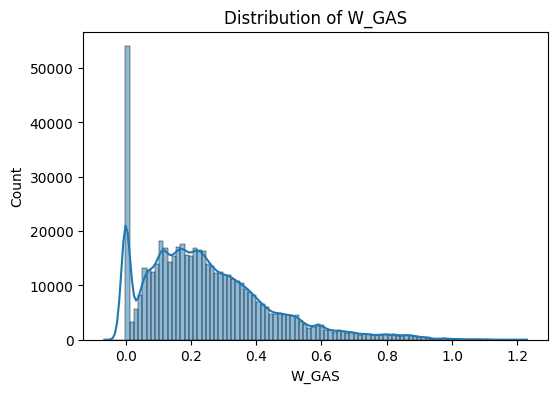

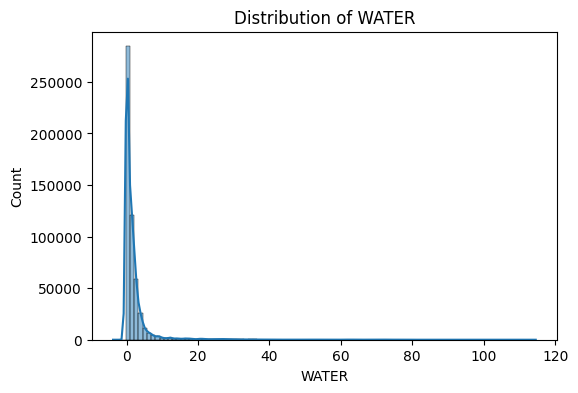

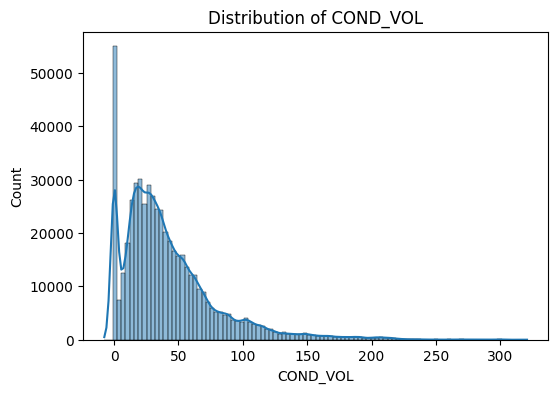

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

targets = ["W_GAS", "WATER", "COND_VOL"]

for col in targets:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=100, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [173]:
def detect_outliers(df_final_model, col):
    Q1 = df_final_model[col].quantile(0.25)
    Q3 = df_final_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_final_model[(df_final_model[col] < lower) | (df_final_model[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
    print(f"Lower: {lower}, Upper: {upper}")

for col in ["WHP", "WHT", "W_GAS", "WATER", "COND_VOL"]:
    detect_outliers(df_final_model, col)

WHP: 0 outliers
Lower: -24.250001907348633, Upper: 158.55000114440918
WHT: 20135 outliers
Lower: 40.5, Upper: 76.5
W_GAS: 16432 outliers
Lower: -0.19641611125000003, Upper: 0.70229809875
WATER: 37171 outliers
Lower: -3.056659236550331, Upper: 5.451346501708031
COND_VOL: 25300 outliers
Lower: -36.34325790405275, Upper: 117.29166030883792


In [174]:
import numpy as np

cols = ["WHP", "WHT", "W_GAS", "WATER", "COND_VOL"]

for col in cols:
    print("\n====================")
    print(f"{col}")

    print("Zeros %:", (df[col] == 0).mean())

    print("Min:", df[col].min())
    print("Max:", df[col].max())

    print("Quantiles:")
    print(df[col].quantile([
        0.01, 0.05, 0.10,
        0.25, 0.50, 0.75,
        0.90, 0.95, 0.99
    ]))


WHP
Zeros %: 0.09407740881507148
Min: 0.0
Max: 694.0
Quantiles:
0.01      0.000000
0.05      0.000000
0.10     36.400002
0.25     41.799999
0.50     63.400002
0.75     87.000000
0.90    100.000000
0.95    106.000000
0.99    121.000000
Name: WHP, dtype: float64

WHT
Zeros %: 0.09994629050125135
Min: -17.77777862548828
Max: 587.0
Quantiles:
0.01     0.0
0.05     0.0
0.10     0.0
0.25    50.0
0.50    59.0
0.75    63.0
0.90    65.0
0.95    66.0
0.99    68.0
Name: WHT, dtype: float64

W_GAS
Zeros %: 0.0968113714944295
Min: -0.06533863
Max: 1.22955966
Quantiles:
0.01    0.000000
0.05    0.000000
0.10    0.010270
0.25    0.110568
0.50    0.217221
0.75    0.348991
0.90    0.504961
0.95    0.617688
0.99    0.855226
Name: W_GAS, dtype: float64

WATER
Zeros %: 0.23506484303026007
Min: -3.777168035507202
Max: 114.572265625
Quantiles:
0.01     0.000000
0.05     0.000000
0.10     0.000000
0.25     0.011335
0.50     0.813275
0.75     2.098209
0.90     4.095388
0.95     7.189141
0.99    27.490186
Nam

In [175]:
for col in ["WATER", "W_GAS", "COND_VOL"]:
    print("\n====", col, "====")

    original_skew = df[col].skew()
    log_skew = np.log1p(df[col]).skew()

    print("Original skew:", original_skew)
    print("Log skew     :", log_skew)


==== WATER ====
Original skew: 7.480274341457578
Log skew     : 1.3899311736019662

==== W_GAS ====
Original skew: 1.0578077673563189
Log skew     : 0.6410003235110983

==== COND_VOL ====
Original skew: 1.816688695720234
Log skew     : -1.3452406973957947


a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [177]:
def extreme_analysis(df_final_model, col):
    q99 = df_final_model[col].quantile(0.99)
    q999 = df_final_model[col].quantile(0.999)

    print(f"\n{col}")
    print("99%:", q99)
    print("99.9%:", q999)

    extreme_count = (df_final_model[col] > q999).sum()
    print("Extreme count (>99.9%):", extreme_count)

for col in ["WHP","WHT","W_GAS","WATER","COND_VOL"]:
    extreme_analysis(df_final_model, col)


WHP
99%: 123.0
99.9%: 140.0
Extreme count (>99.9%): 0

WHT
99%: 69.0
99.9%: 71.0
Extreme count (>99.9%): 0

W_GAS
99%: 0.86150638
99.9%: 1.03408956
Extreme count (>99.9%): 0

WATER
99%: 28.765331268310547
99.9%: 70.89387512207031
Extreme count (>99.9%): 0

COND_VOL
99%: 187.80442810058597
99.9%: 242.224365234375
Extreme count (>99.9%): 0
